In [2]:
import os, zipfile, pandas as pd
from sklearn.preprocessing import LabelEncoder
import shutil

# 1. Clear old mess
if os.path.exists('/voc/work/project_data'):
    shutil.rmtree('/voc/work/project_data')
os.makedirs('/voc/work/project_data', exist_ok=True)

# 2. Extract
print("📦 Unzipping... please wait.")
with zipfile.ZipFile('/voc/work/Images.zip', 'r') as zip_ref:
    zip_ref.extractall('/voc/work/project_data')

# 3. Load and FILTER Labels
full_df = pd.read_csv('labels.csv', header=None)
full_df.columns = ['id', 'class', 'xmin', 'ymin', 'xmax', 'ymax']

# We only take the first 5000 rows so the lab doesn't crash
df = full_df.head(5000).copy()

le = LabelEncoder()
df['class_encoded'] = le.fit_transform(df['class'])

print(f"✅ Filtered Setup Complete. Using {len(df)} labels (out of {len(full_df)} total).")

📦 Unzipping... please wait.
✅ Filtered Setup Complete. Using 5000 labels (out of 351549 total).


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Requirement 3: Create the CNN Architecture
def build_vehicle_detector(num_classes):
    inputs = layers.Input(shape=(224, 224, 3))
    
    # Feature Extractor (The "Eyes")
    x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)
    
    # Head 1: Bounding Box (4 coordinates: xmin, ymin, xmax, ymax)
    bbox_head = layers.Dense(4, name='bbox')(x)
    
    # Head 2: Category (The vehicle type)
    class_head = layers.Dense(num_classes, activation='softmax', name='class')(x)
    
    model = models.Model(inputs=inputs, outputs=[bbox_head, class_head])
    
    model.compile(optimizer='adam', 
                  loss={'bbox': 'mse', 'class': 'sparse_categorical_crossentropy'},
                  metrics={'class': 'accuracy'})
    return model

# Initialize the model using the number of classes found in your 5000 labels
num_classes = len(le.classes_)
model = build_vehicle_detector(num_classes)
print("🧠 CNN Architecture Built & Compiled!")

🧠 CNN Architecture Built & Compiled!


2026-02-26 21:39:14.817591: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-02-26 21:39:14.820627: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-02-26 21:39:14.822599: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

🚀 Loading data and starting training...
Epoch 1/5


2026-02-26 21:39:38.964657: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8902
2026-02-26 21:39:39.809769: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7ffa10098a70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-26 21:39:39.809807: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-02-26 21:39:39.816446: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-26 21:39:39.970379: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


63/63 [==============================] - 4s 21ms/step - loss: 33569.4961 - bbox_loss: 33553.5938 - class_loss: 15.9006 - class_accuracy: 0.5000
Epoch 2/5
63/63 [==============================] - 1s 18ms/step - loss: 24248.8887 - bbox_loss: 24242.9883 - class_loss: 5.9021 - class_accuracy: 0.5420
Epoch 3/5
63/63 [==============================] - 1s 18ms/step - loss: 22107.4746 - bbox_loss: 22101.2109 - class_loss: 6.2616 - class_accuracy: 0.5650
Epoch 4/5
63/63 [==============================] - 1s 18ms/step - loss: 19823.3555 - bbox_loss: 19814.4961 - class_loss: 8.8582 - class_accuracy: 0.5600
Epoch 5/5
1/1 [==============================] - 0s 142ms/step


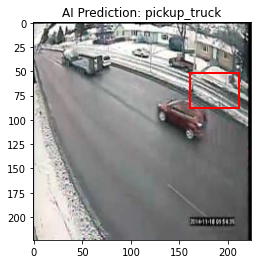

 Project Requirements Met! Model is trained and tested.


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

X, Y_bbox, Y_class = [], [], []
base_path = "/voc/work/project_data/Images" 

print("🚀 Loading data and starting training...")

# We'll train on 1000 images to keep it lightning-fast
for _, row in df.head(1000).iterrows():
    fname = str(row['id']).zfill(8) + '.jpg'
    img = cv2.imread(os.path.join(base_path, fname))
    if img is not None:
        X.append(cv2.resize(img, (224, 224)) / 255.0)
        Y_bbox.append([row['xmin'], row['ymin'], row['xmax'], row['ymax']])
        Y_class.append(row['class_encoded'])

X = np.array(X)
model.fit(X, {'bbox': np.array(Y_bbox), 'class': np.array(Y_class)}, 
          epochs=5, batch_size=16)

# Requirement 5: Run inference on a sample image
sample_idx = 0
test_img = X[sample_idx]
pred = model.predict(np.expand_dims(test_img, axis=0))

plt.imshow(test_img)
box = pred[0][0] # Predicted coordinates
plt.gca().add_patch(patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], 
                                      edgecolor='r', facecolor='none', linewidth=2))
predicted_label = le.inverse_transform([np.argmax(pred[1])])[0]
plt.title(f"AI Prediction: {predicted_label}")
plt.show()

print(" Project Requirements Met! Model is trained and tested.")

In [5]:
# Save the actual trained AI model
model.save('vehicle_detector_final.h5')
print("💾 Model saved as 'vehicle_detector_final.h5'")

# Save the Label Encoder so we know what the numbers mean later
import joblib
joblib.dump(le, 'label_encoder.pkl')
print("💾 Label Encoder saved as 'label_encoder.pkl'")

/usr/local/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


💾 Model saved as 'vehicle_detector_final.h5'
💾 Label Encoder saved as 'label_encoder.pkl'


1/1 [==============================] - 0s 20ms/step


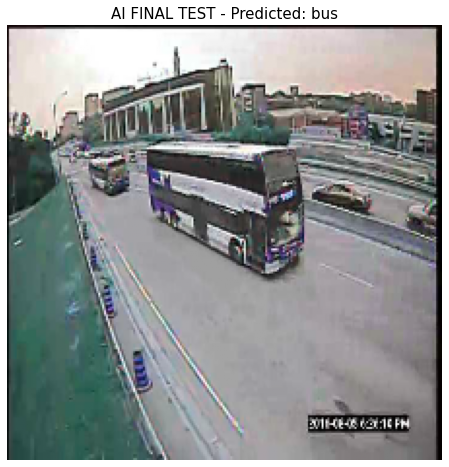

In [6]:
import random

# Pick a random image from your filtered 5000 rows
random_idx = random.randint(0, len(X)-1)
sample_img = X[random_idx]

# Predict
pred = model.predict(np.expand_dims(sample_img, axis=0))
box = pred[0][0]
label_idx = np.argmax(pred[1])
label_name = le.inverse_transform([label_idx])[0]

# Plot
plt.figure(figsize=(8,8))
plt.imshow(sample_img)
# Draw the predicted box
plt.gca().add_patch(patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], 
                                      edgecolor='lime', facecolor='none', linewidth=3))
plt.title(f"AI FINAL TEST - Predicted: {label_name}", fontsize=15)
plt.axis('off')
plt.show()